# 01 — Sequential tSNPE

Supongamos que solo podemos permitirnos 3000 simulaciones en total. Si simulamos todas de una con el prior amplio, la mayoría caen fuera de la zona de alta probabilidad y los modelos aprenden poco.

La solución es tSNPE secuencial: primero simulamos una cantidad pequeña para encontrar la zona de alta probabilidad, luego truncamos el prior y simulamos el resto concentrando el esfuerzo donde importa.

En este tutorial:
1. Intento 1: 3000 simulaciones de golpe (prior amplio) — vemos el problema
2. Borramos todo con `delete_last_round`
3. Intento 2: 1000 sims (round 0) → `update_proposal` → 2000 sims (round 1)

In [10]:
import os
import shutil
import json
import torch
import matplotlib.pyplot as plt
from torch import nn
import zbi

%matplotlib inline

## 1. Simulador gaussiano

Mismo modelo lineal del tutorial 00: señal en 50 puntos con pendiente $a$ e intercepto $b$, más ruido Gaussiano.

$$x_i = a \cdot g_i + b + \epsilon_i, \quad \epsilon_i \sim \mathcal{N}(0, 0.5)$$

In [11]:
class SimuladorLineal(zbi.Simulator):
    def __init__(self):
        super().__init__()
        self.x_grid = torch.linspace(-5, 5, 50)

    def simulate(self, theta: torch.Tensor, seed: int | None = None) -> torch.Tensor:
        if seed is not None:
            torch.manual_seed(seed)
        a, b = theta[0].item(), theta[1].item()
        return a * self.x_grid + b + 0.5 * torch.randn(50)

## 2. Red de embedding

Proyecta el dato de 50 dimensiones a 2 con una capa lineal.

In [12]:
class EmbeddingNet(nn.Module):
    def __init__(self, dim_in: int = 50, dim_out: int = 2):
        super().__init__()
        self.net = nn.Linear(dim_in, dim_out)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x)

## 3. Observación y experimento

Prior Uniforme en $[0.8, 1.2] \times [0.2, 0.8]$. Valor verdadero: $\theta_{\text{true}} = (1.0, 0.5)$.

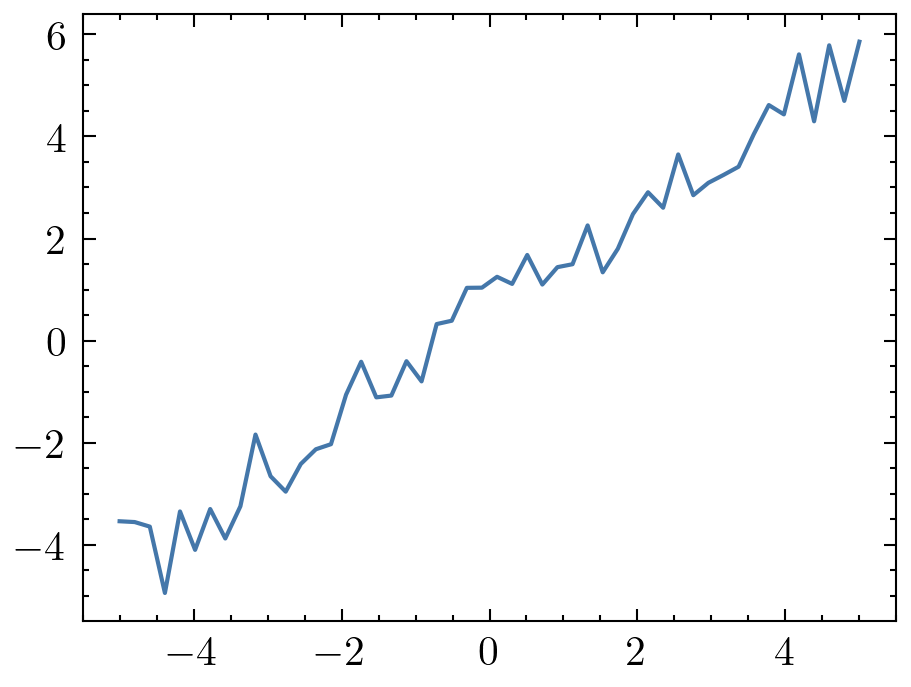

In [13]:
x_grid = torch.linspace(-5, 5, 50)
x_o = zbi.simulate_obs(SimuladorLineal(), theta_true=(1.0, 0.5), seed=42)
plt.plot(x_grid, x_o[0])

In [14]:
run_dir = "runs/tutorial_01"
if os.path.exists(run_dir):
    shutil.rmtree(run_dir)

zbi.init(
    run_dir=run_dir, x_o=x_o,
    simulator_class=SimuladorLineal,
    embedding_class=EmbeddingNet,
    embedding_kwargs=dict(dim_in=50, dim_out=2),
    prior_low=(0.8, 0.2), prior_high=(1.2, 0.8),
    dim_theta=2, dim_x=50,
    zarr_N=20000, zarr_chunk_size=128,
    maf_kwargs=dict(
        hidden_features=32, num_transforms=5,
        num_blocks=2, dropout_probability=0.0,
        use_batch_norm=False
    )
)

Experiment initialized: runs/tutorial_01


---
## Intento 1: 3000 simulaciones de golpe

### 4. Round 0 — Simulación (3000 sims)

Simulamos 3000 datos muestreando del prior original (Uniforme en $[0.8, 1.2] \times [0.2, 0.8]$).

In [15]:
zbi.simulate(run_dir=run_dir, round=0, n_sims=3000, seed=1)

Simulating: 100%|██████████| 3000/3000 [00:00<00:00, 4777.86it/s]

Round 0: 3000 new sims, 3000 accumulated (offset=0)


### 5. Round 0 — Entrenamiento

Entrenamos 3 modelos independientes.

In [16]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

tags_r0 = ['a', 'b', 'c']
for tag in tags_r0:
    zbi.train(
        run_dir=run_dir,
        round=0,
        n_sims=3000,
        offset=0,
        device=device,
        batch_size=128,
        lr=0.0005,
        max_epochs=100,
        stop_after_epochs=100,
        tag=tag,
        interest_dims=None,
        load_to_ram=True
    )

Using device: cuda
Using simulations: offset=0, n_sims=3000
Epoch   0  train_loss=0.9494  val_loss=0.1479
Epoch   1  train_loss=-0.2630  val_loss=-0.5596
Epoch   2  train_loss=-0.7851  val_loss=-1.0988
Epoch   3  train_loss=-1.3286  val_loss=-1.5463
Epoch   4  train_loss=-1.6828  val_loss=-1.7925
Epoch   5  train_loss=-1.8416  val_loss=-1.8845
Epoch   6  train_loss=-1.9162  val_loss=-1.8992
Epoch   7  train_loss=-1.9704  val_loss=-1.9285
Epoch   8  train_loss=-1.9956  val_loss=-1.9702
Epoch   9  train_loss=-2.0189  val_loss=-1.9683
Epoch  10  train_loss=-2.0306  val_loss=-2.0159
Epoch  11  train_loss=-2.0444  val_loss=-2.0154
Epoch  12  train_loss=-2.0607  val_loss=-1.9990
Epoch  13  train_loss=-2.0753  val_loss=-2.0591
Epoch  14  train_loss=-2.0890  val_loss=-2.0533
Epoch  15  train_loss=-2.1349  val_loss=-2.1787
Epoch  16  train_loss=-2.2490  val_loss=-2.3167
Epoch  17  train_loss=-2.4448  val_loss=-2.4982
Epoch  18  train_loss=-2.6482  val_loss=-2.6902
Epoch  19  train_loss=-2.8032 

### 6. Round 0 — Resultados: los modelos difieren mucho

Con solo 3000 simulaciones del prior amplio, los 3 modelos producen posteriores muy distintos entre sí. Esto indica que el entrenamiento no fue estable: la información contenida en las simulaciones no fue suficiente.

Removed no burn in
Removed no burn in
Removed no burn in


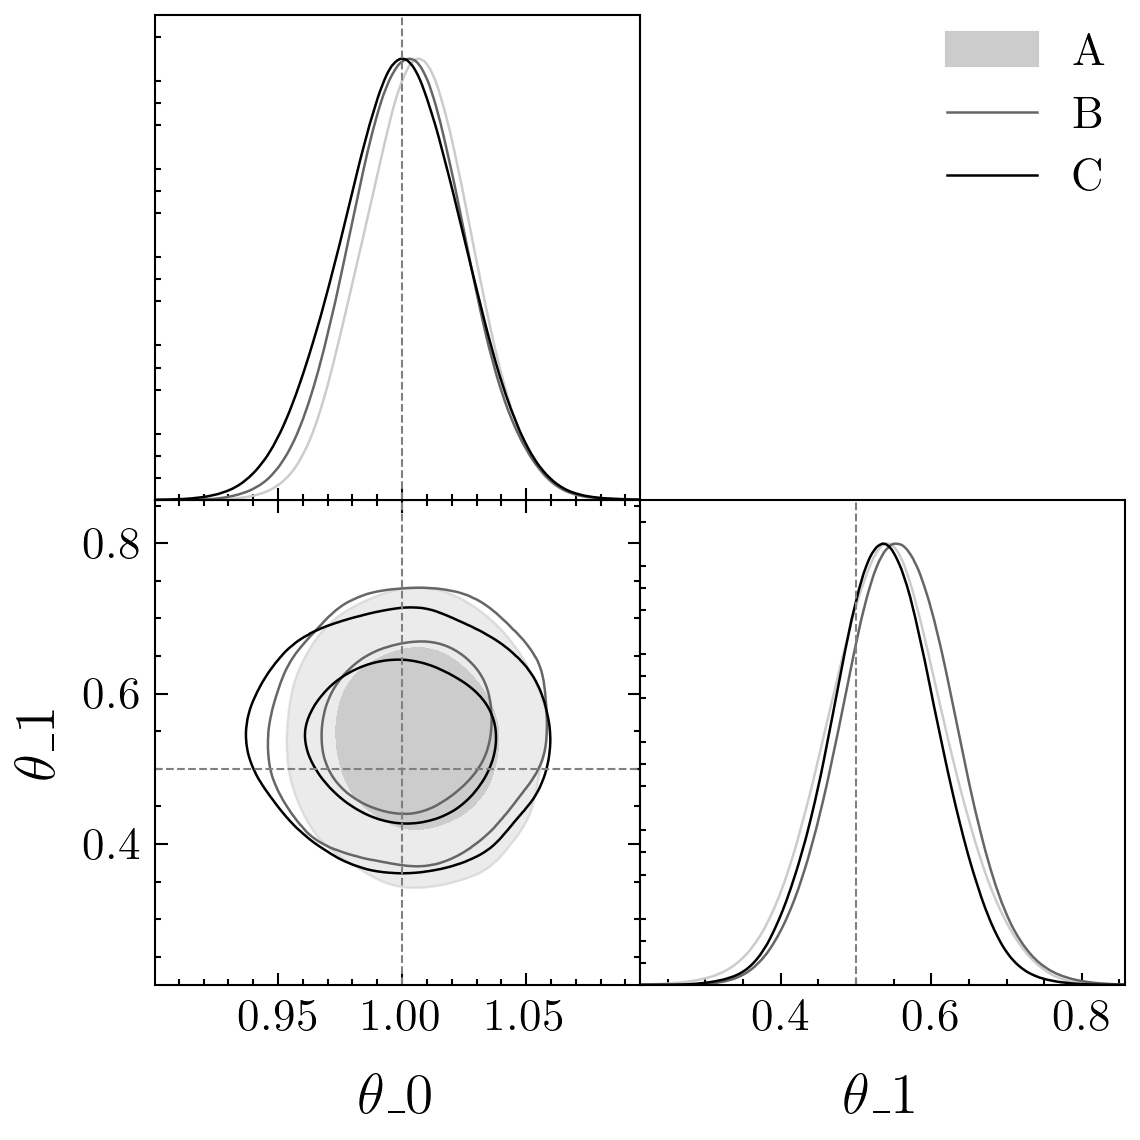

In [17]:
all_samples_r0 = []
for tag in tags_r0:
    samples = zbi.sample_model(
        run_dir=run_dir,
        checkpoint=f"round_00000_3000_{tag}.pt",
        n_samples=10_000
    )
    all_samples_r0.append(samples)

zbi.plot_ppc(
    all_samples=all_samples_r0,
    param_names=[r'\theta_0', r'\theta_1'],
    true_parameter=[1.0, 0.5],
    sample_labels=["A", "B", "C"],
    legend_fontsize=11,
    filled=[True, False, False],
    sample_colors=["#cccccc", "#666666", "#000000"],
    gdist_fine_bins=2000,
    gdist_scaling_factor=0.1
)

### 7. Comparación con los límites del prior

Si superponemos los límites del prior (el rectángulo gris), vemos que la posterior es mucho más pequeña que el prior. La mayoría de las 3000 simulaciones cayeron en regiones de baja probabilidad, desperdiciando presupuesto computacional.

Removed no burn in
Removed no burn in
Removed no burn in


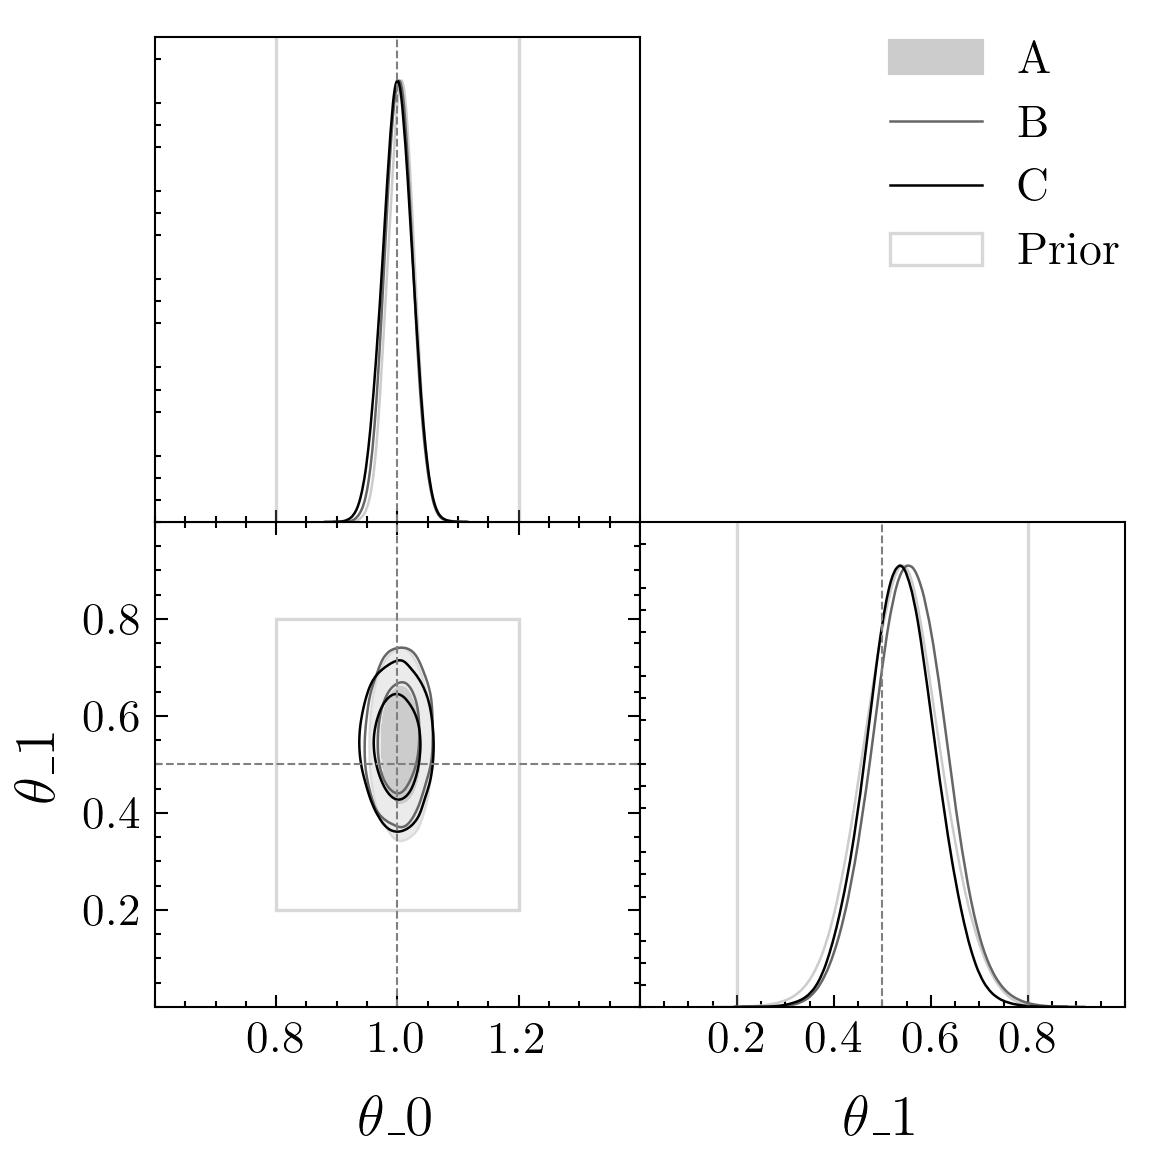

In [18]:
zbi.plot_ppc(
    all_samples=all_samples_r0,
    param_names=[r'\theta_0', r'\theta_1'],
    true_parameter=[1.0, 0.5],
    sample_labels=["A", "B", "C"],
    legend_fontsize=11,
    filled=[True, False, False],
    sample_colors=["#cccccc", "#666666", "#000000"],
    gdist_fine_bins=2000,
    gdist_scaling_factor=0.1,
    limits=[(0.6, 1.4), (0.0, 1.0)],
    bounds_list=[{
        "low": [0.8, 0.2],
        "high": [1.2, 0.8],
        "label": "Prior"
    }]
)

### 8. Diagnóstico

El problema es claro: el prior es demasiado amplio y las simulaciones se distribuyen uniformemente en todo el espacio de parámetros. Solo una fracción pequeña de ellas cae en la región compatible con la observación. Con 3000 simulaciones, esto no alcanza para aprender un buen posterior.

La solución es truncar el prior para concentrar las simulaciones donde importa.

---
## Borramos todo y empezamos de cero

Usamos `zbi.delete_last_round` para borrar las simulaciones del round 0 y empezar con el enfoque secuencial.

In [19]:
zbi.delete_last_round(run_dir)

Deleted round 0: cleared 3000 sims at offset=0


---
## Intento 2: Enfoque secuencial

Ahora dividimos las 3000 simulaciones en dos rondas:
- **Round 0**: 1000 sims del prior amplio → entrenar modelos → encontrar la zona de alta probabilidad
- **Round 1**: 2000 sims del prior truncado → entrenar modelos con datos concentrados

### 9. Round 0 — Simulación (1000 sims)

In [20]:
zbi.simulate(run_dir=run_dir, round=0, n_sims=1000, seed=1)

Simulating: 100%|██████████| 1000/1000 [00:00<00:00, 5808.09it/s]

Round 0: 1000 new sims, 1000 accumulated (offset=0)


### 10. Round 0 — Entrenamiento

In [21]:
tags_r0 = ['a', 'b', 'c']
for tag in tags_r0:
    zbi.train(
        run_dir=run_dir,
        round=0,
        n_sims=1000,
        offset=0,
        device=device,
        batch_size=128,
        lr=0.0005,
        max_epochs=200,
        stop_after_epochs=200,
        tag=tag,
        interest_dims=None,
        load_to_ram=True
    )

Using simulations: offset=0, n_sims=1000
Epoch   0  train_loss=1.1013  val_loss=0.7741
Epoch   1  train_loss=0.5789  val_loss=0.2636
Epoch   2  train_loss=0.0926  val_loss=-0.1985
Epoch   3  train_loss=-0.3317  val_loss=-0.5681
Epoch   4  train_loss=-0.6448  val_loss=-0.8054
Epoch   5  train_loss=-0.8638  val_loss=-0.9947
Epoch   6  train_loss=-1.0492  val_loss=-1.1761
Epoch   7  train_loss=-1.2060  val_loss=-1.3243
Epoch   8  train_loss=-1.3335  val_loss=-1.4526
Epoch   9  train_loss=-1.4806  val_loss=-1.6003
Epoch  10  train_loss=-1.6507  val_loss=-1.7547
Epoch  11  train_loss=-1.8101  val_loss=-1.8822
Epoch  12  train_loss=-1.9548  val_loss=-1.9801
Epoch  13  train_loss=-2.0738  val_loss=-2.0502
Epoch  14  train_loss=-2.1726  val_loss=-2.0917
Epoch  15  train_loss=-2.2536  val_loss=-2.1398
Epoch  16  train_loss=-2.3089  val_loss=-2.1735
Epoch  17  train_loss=-2.3584  val_loss=-2.2108
Epoch  18  train_loss=-2.4055  val_loss=-2.2524
Epoch  19  train_loss=-2.4427  val_loss=-2.2684
Epoc

### 11. Round 0 — Actualizar propuesta

`update_proposal` toma los checkpoints del round 0, samplea de la posterior, y calcula un bounding box alrededor de las muestras de alta probabilidad. Esto define un prior más acotado para la siguiente ronda.

El parámetro `threshold=0.001` retiene muestras con `log_prob > max(log_prob) + log(0.001)`.

In [26]:
checkpoints_r0 = [f"round_00000_1000_{tag}.pt" for tag in tags_r0]

zbi.update_proposal(
    run_dir=run_dir,
    checkpoint=checkpoints_r0,
    threshold=0.001,
    n_samples=10_000
)

### 12. Inspeccionar el bounding box

Removed no burn in
Removed no burn in
Removed no burn in


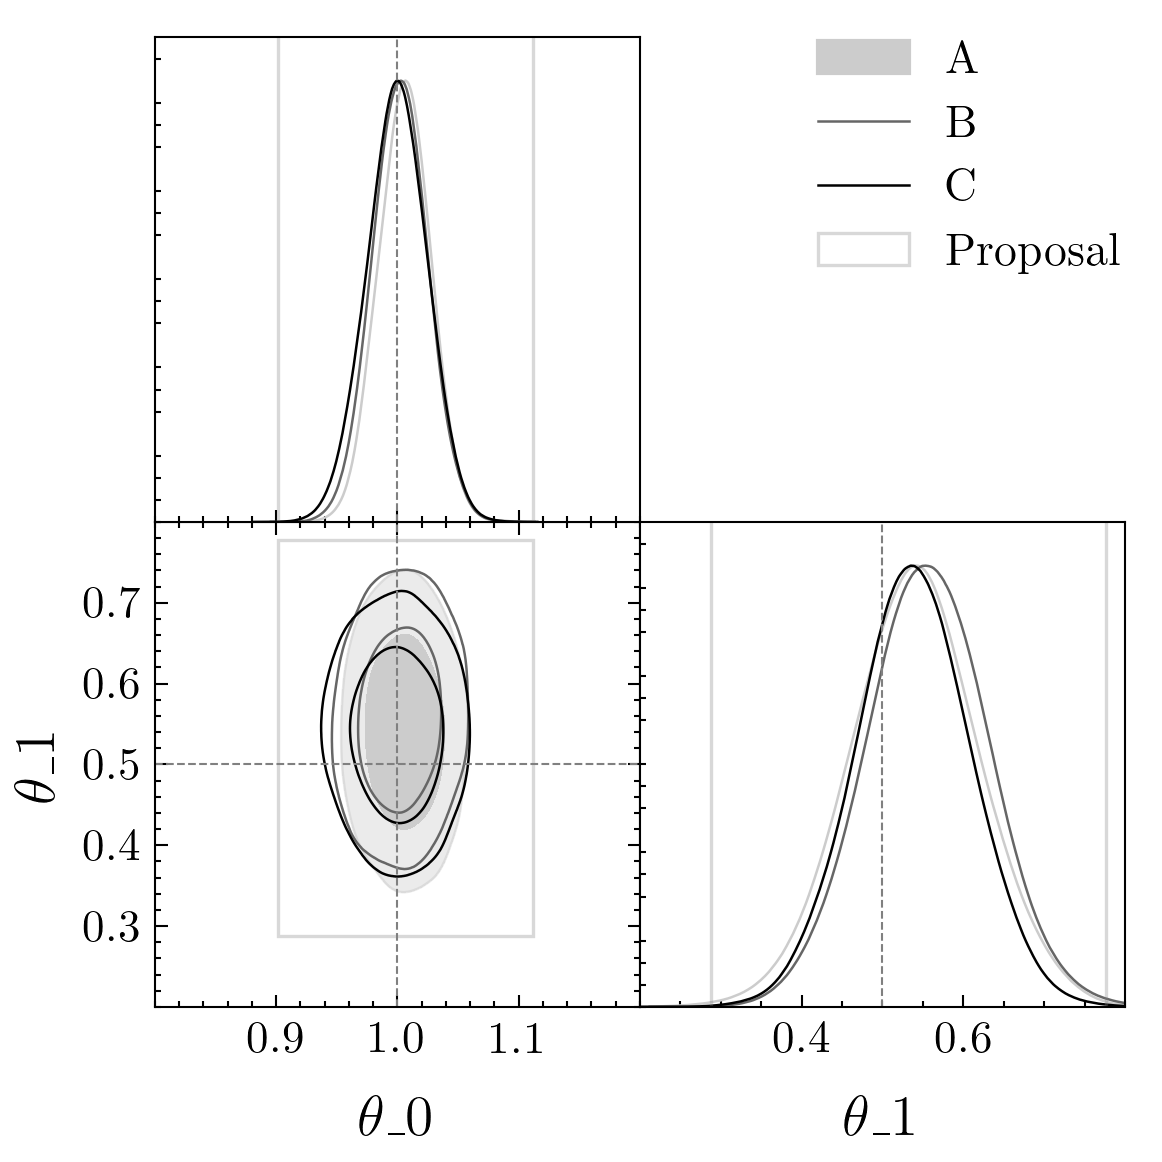

In [33]:
with open(f"{run_dir}/proposal.json") as f:
    proposal = json.load(f)

zbi.plot_ppc(
    all_samples=all_samples_r0,
    param_names=[r'\theta_0', r'\theta_1'],
    true_parameter=[1.0, 0.5],
    sample_labels=["A", "B", "C"],
    legend_fontsize=11,
    filled=[True, False, False],
    sample_colors=["#cccccc", "#666666", "#000000"],
    gdist_fine_bins=2000,
    gdist_scaling_factor=0.1,
    bounds_list=[{
        "low": proposal['bounds']['low'],
        "high": proposal['bounds']['high'],
        "label": "Proposal"
    }],
    limits=[(0.8, 1.2), (0.2, 0.8)]
)

### 13. Round 1 — Simulación (2000 sims)

Ahora `zbi.simulate` con `round=1` lee `proposal.json` automáticamente y construye un `TruncatedBoxPrior`. Las 2000 simulaciones se concentran en la región de mayor probabilidad.

In [30]:
zbi.simulate(run_dir=run_dir, round=1, n_sims=2000, seed=2)

Simulating: 100%|██████████| 2000/2000 [00:00<00:00, 7154.49it/s]

Round 1: 2000 new sims, 2000 accumulated (offset=1000)


### 14. Round 1 — Entrenamiento

Entrenamos 3 modelos nuevos. Usamos todas las 3000 simulaciones (1000 del round 0 + 2000 del round 1) con `offset=0`.

In [31]:
tags_r1 = ['d', 'e', 'f']
for tag in tags_r1:
    zbi.train(
        run_dir=run_dir,
        round=1,
        n_sims=3000,
        offset=0,
        device=device,
        batch_size=128,
        lr=0.0005,
        max_epochs=200,
        stop_after_epochs=200,
        tag=tag,
        interest_dims=None,
        load_to_ram=True
    )

Using simulations: offset=0, n_sims=3000
Epoch   0  train_loss=0.4975  val_loss=-0.3302
Epoch   1  train_loss=-0.9224  val_loss=-1.3420
Epoch   2  train_loss=-1.4494  val_loss=-1.5314
Epoch   3  train_loss=-1.6595  val_loss=-1.8740
Epoch   4  train_loss=-2.0818  val_loss=-2.2842
Epoch   5  train_loss=-2.4588  val_loss=-2.5525
Epoch   6  train_loss=-2.6821  val_loss=-2.7348
Epoch   7  train_loss=-2.8784  val_loss=-3.0399
Epoch   8  train_loss=-3.0559  val_loss=-3.1977
Epoch   9  train_loss=-3.1883  val_loss=-3.3056
Epoch  10  train_loss=-3.2944  val_loss=-3.3649
Epoch  11  train_loss=-3.3718  val_loss=-3.4873
Epoch  12  train_loss=-3.4361  val_loss=-3.4020
Epoch  13  train_loss=-3.4779  val_loss=-3.4572
Epoch  14  train_loss=-3.5088  val_loss=-3.5111
Epoch  15  train_loss=-3.5311  val_loss=-3.5136
Epoch  16  train_loss=-3.5572  val_loss=-3.5281
Epoch  17  train_loss=-3.5660  val_loss=-3.5288
Epoch  18  train_loss=-3.5767  val_loss=-3.5234
Epoch  19  train_loss=-3.6010  val_loss=-3.5023


### 15. Comparación final

Los modelos del round 1 (con prior truncado) deberían ser mucho más consistentes entre sí y más concentrados alrededor del valor verdadero, usando el mismo presupuesto de 3000 simulaciones.

Removed no burn in
Removed no burn in
Removed no burn in


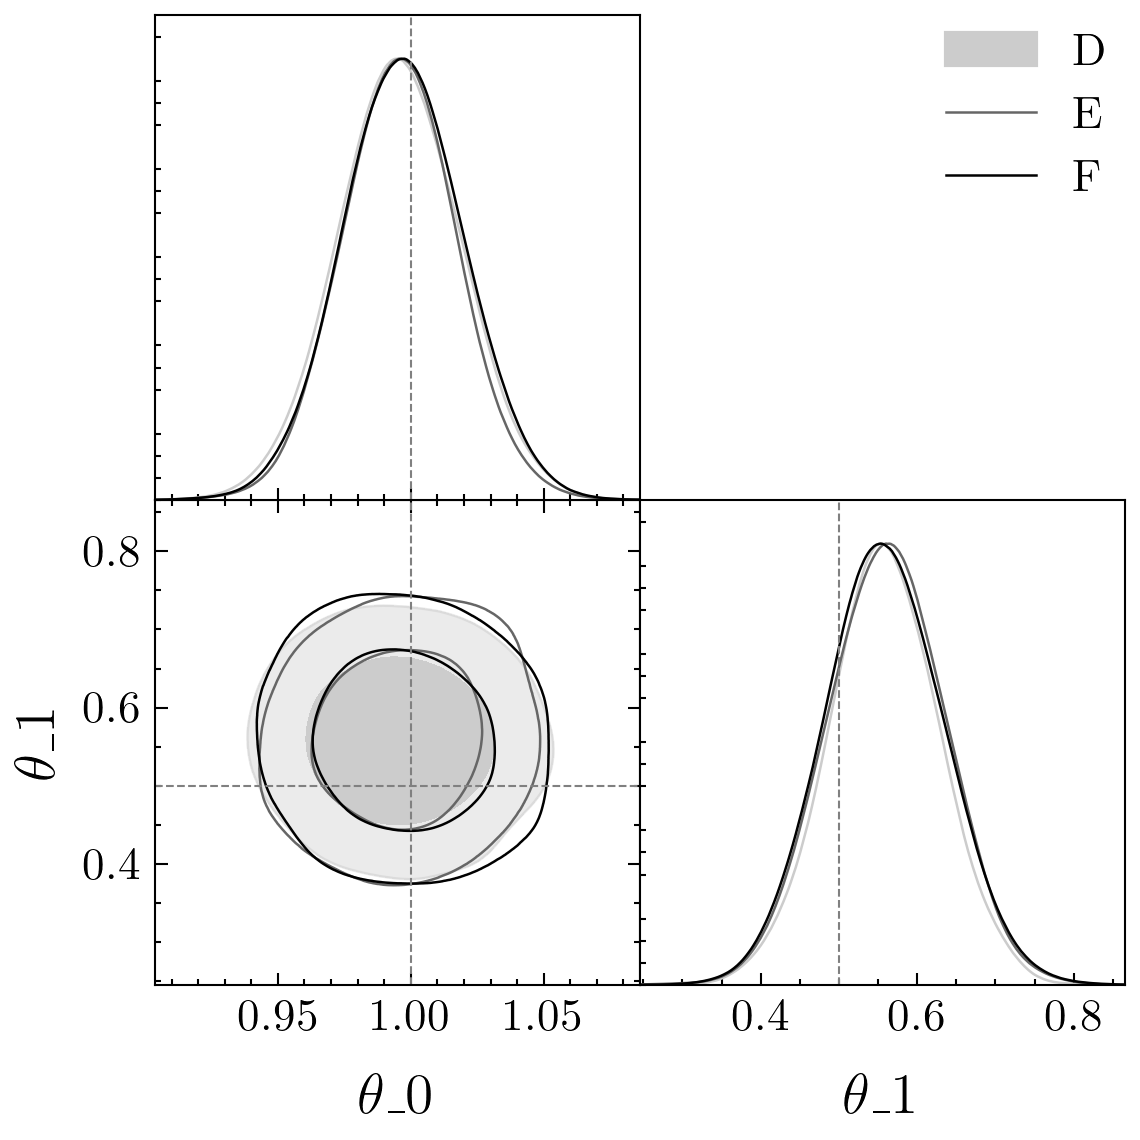

In [32]:
all_samples_r1 = []
for tag in tags_r1:
    samples = zbi.sample_model(
        run_dir=run_dir,
        checkpoint=f"round_00001_3000_{tag}.pt",
        n_samples=10_000
    )
    all_samples_r1.append(samples)

zbi.plot_ppc(
    all_samples=all_samples_r1,
    param_names=[r'\theta_0', r'\theta_1'],
    true_parameter=[1.0, 0.5],
    sample_labels=["D", "E", "F"],
    legend_fontsize=11,
    filled=[True, False, False],
    sample_colors=["#cccccc", "#666666", "#000000"],
    gdist_fine_bins=2000,
    gdist_scaling_factor=0.1
)

## Resumen

| Función | Descripción |
|---------|-------------|
| `zbi.update_proposal()` | Calcula bounding box para truncar el prior |
| `zbi.delete_last_round()` | Borra las simulaciones de una ronda |
